경사하강법을 통해 직선이 데이터를 점점 잘 설명해가도록 바뀌는 과정이다.  
학습이 되면 -> w, b 이 조금씩 수정되면서, 손실값은 점점 줄어든다.

epoch=0, loss=105.7228, w=0.2150, b=0.1995
epoch=200, loss=1.1733, w=4.6687, b=5.4308
epoch=400, loss=1.0422, w=4.3365, b=5.8074
epoch=600, loss=1.0062, w=4.1616, b=6.0045
epoch=800, loss=0.9962, w=4.0698, b=6.1079
최종 w: 4.021813642697164
최종 b: 6.162031224717461


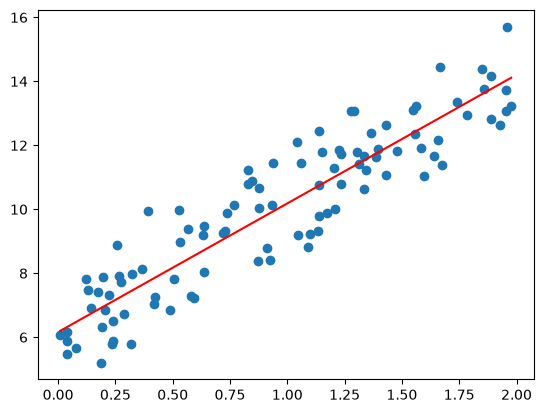

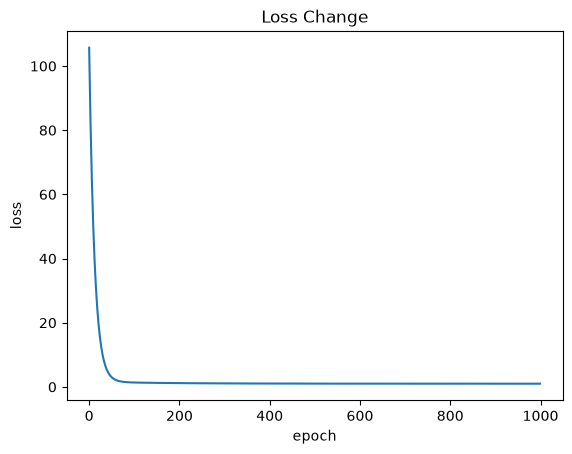

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성
np.random.seed(0)
X = 2 * np.random.rand(100, 1)              # 0 ~ 2 데이터 100개
y = 6 + 4 * X + np.random.randn(100, 1)     # y = 6 + 4x + 오차

# 2. 초기값 설정
w = 0                   # 기울기
b = 0                   # 절편
learning_rate = 0.01    # 학습률
epochs = 1000           # 반복 횟수
n = len(X)              # 데이터 갯수

loss_history = []

# 3. 경사하강법 반복
for epoch in range(epochs):
    # 예측값
    y_pred = w * X + b      # 예측값 계산

    # 오차
    error = y_pred - y      # 예측값과 손실값의 차이 계산

    # 손실값(MSE)
    loss = np.mean(error ** 2)  # MSE 손실값 계산
    loss_history.append(loss)   # 손실값 저장

    # 기울기 계산
    w_grad = (2 / n) * np.sum(X * error)    # w 에 대한 기울기 계산
    b_grad = (2 / n) * np.sum(error)        # b 에 대한 기울기 계산

    # 파라미터 업데이트
    w = w - learning_rate * w_grad          # x 값 정렬
    b = b - learning_rate * b_grad          

    # 중간 결과 확인
    if epoch % 200 == 0:
        print(f"epoch={epoch}, loss={loss:.4f}, w={w:.4f}, b={b:.4f}")

print("최종 w:", w)
print("최종 b:", b)

# 4. 학습된 직선 시각화
X_sorted = np.sort(X, axis=0)           # x 값 정렬
y_pred_sorted = w * X_sorted + b        # 정렬된 x 를 기준으로 예측값

plt.scatter(X, y)                       # 실제 데이터 산점도
plt.plot(X_sorted, y_pred_sorted, color="red")  # 학습된 회귀 직선
plt.show()

# 5. 손실값 변화 시각화
plt.plot(loss_history)      # 손시값 변화 그래프
plt.xlabel("epoch")         
plt.ylabel("loss")  
plt.title("Loss Change")
plt.show()

03-03-07. 선형 회귀 예제

기울기(coefficient): 2.0
절편(intercept): -0.20000000000000018
MSE: 0.15999999999999992
R^2 Score: 0.9803921568627451


c:\Users\MoonSungHo\skn34-st\ML\ML_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MoonSungHo\skn34-st\ML\ML_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MoonSungHo\skn34-st\ML\ML_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MoonSungHo\skn34-st\ML\ML_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MoonSungHo\skn34-st\ML\ML_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABL

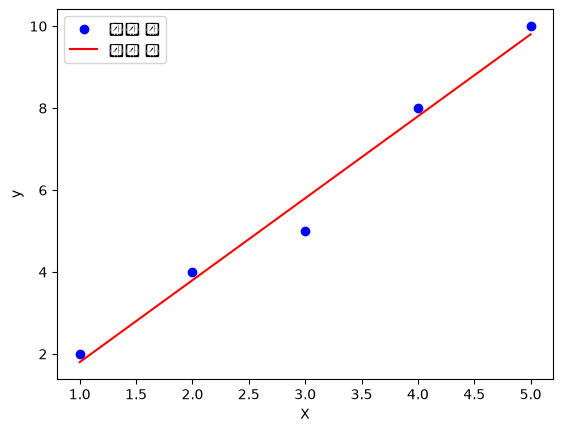

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 데이터 생성 (대괄호 계수로 차원판단)
X = np.array([[1], [2], [3], [4], [5]])     # 2차원 데이터
y = np.array([2, 4, 5, 8, 10])              # 1차원

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)     # fir() : 모델학습 (w, b 찾아냄)

# 예측 값 계산
y_pred = model.predict(X)

# 평가 지표 계산
mse = mean_squared_error(y, y_pred)     # MSE 계산  
r2 = r2_score(y, y_pred)                # R2 결정계수

print(f'기울기(coefficient): {model.coef_[0]}')     # 학습된 기울기 w
print(f'절편(intercept): {model.intercept_}')       # 학습된 절편 b
print(f'MSE: {mse}')        # 평균 제곱오차
print(f'R^2 Score: {r2}')   # R2 결정계수

# 결과 시각화
plt.scatter(X, y, color='blue', label='실제 값')    # 실제 데이터 산점도
plt.plot(X, y_pred, color='red', label='예측 값')   # 예측 데이터 회귀선
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

03-03-08. 다중 선형 회귀

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 데이터 생성
X = np.array([[1, 2100], [2, 2500], [3, 1800], [4, 2200], [5, 1700]])
y = np.array([500, 550, 480, 530, 475])

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)

# 예측 값 계산
y_pred = model.predict(X)

# 평가 지표 계산
mse = mean_squared_error(y, y_pred)

r2 = r2_score(y, y_pred)   

print(f'회귀 계수(coefficient): {model.coef_}')
print(f'절편(intercept): {model.intercept_}')
print(f'MSE: {mse}')
print(r2)

회귀 계수(coefficient): [5.36082474 0.11237113]
절편(intercept): 259.4329896907218
MSE: 3.0927835051547214
0.9963004981995757


다항회귀


c:\Users\MoonSungHo\skn34-st\ML\ML_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MoonSungHo\skn34-st\ML\ML_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MoonSungHo\skn34-st\ML\ML_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MoonSungHo\skn34-st\ML\ML_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MoonSungHo\skn34-st\ML\ML_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE T

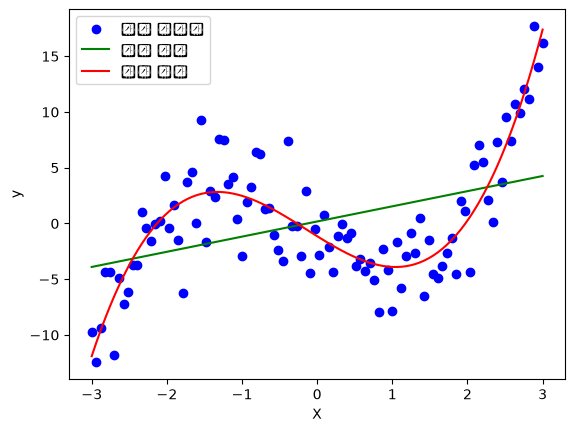

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures    # 다항특성변환

# 데이터 생성
np.random.seed(0)
# reshape(-1 넣으면 지정한 열갯수에 맞춰 데이터를 넣어준다. , 열지정) :
X = np.linspace(-3, 3, 100).reshape(-1, 1)      # -3 ~ 3까지 2차원 (100, 1)  
y = X**3 - 4 * X + np.random.randn(100, 1) * 3  # 3 차함수 + 오차

# 1. 일반 선형 회귀
linear_model = LinearRegression()
linear_model.fit(X, y)                      # 학습
y_linear_pred = linear_model.predict(X)     # 예측값

# 2. 다항 특성 변환
poly_features = PolynomialFeatures(degree=3, include_bias=False)    # 3차 특성
X_poly = poly_features.fit_transform(X)     # X -> X^2 , X^3 ...  등 변환

# 3. 다항 회귀 모델 학습
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly_pred = poly_model.predict(X_poly)

# 4. 결과 시각화
plt.scatter(X, y, color="blue", label="실제 데이터")
plt.plot(X, y_linear_pred, color="green", label="선형 회귀")
plt.plot(X, y_poly_pred, color="red", label="다항 회귀")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

학습곡선 그리기

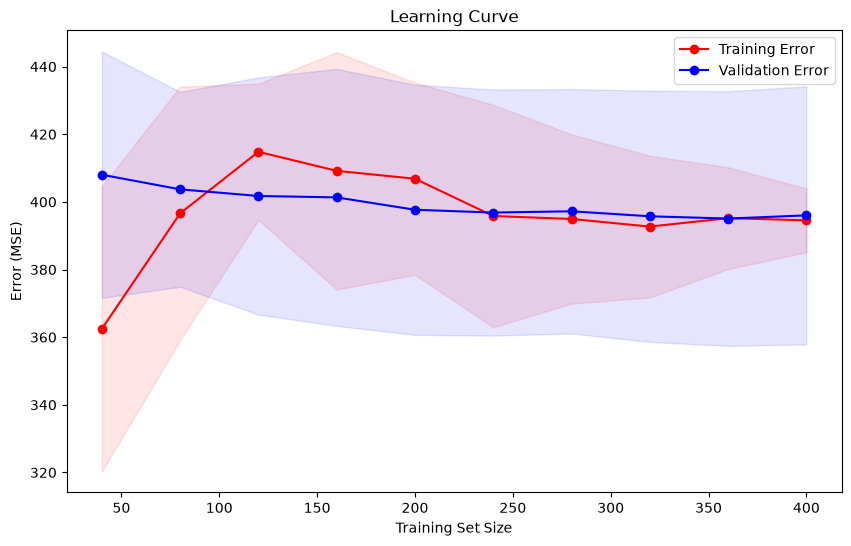

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression        # 회귀용 예제 데이터

# 1. 데이터 생성
X, y = make_regression(     
    n_samples=500,  # 샘플 갯수
    n_features=1,   
    noise=20,       # 데이터 오차추가
    random_state=42 
)

# 2. 학습 곡선 계산
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(),     # 사용할 모델
    X,                      # 입력 데이터
    y,                      # 정답 데이터
    cv=5,                   # 교차검증
    scoring="neg_mean_squared_error",   # MES
    train_sizes=np.linspace(0.1, 1.0, 10),  # 학습데이터 비율 0.1 부터 1까지 10단계
    shuffle=True,       # 데이터 섞기
    random_state=42     
)

# 3. 평균과 표준편차 계산
# neg_mean_squared_error는 음수로 반환되므로 -를 붙여 양수 MSE로 변환
train_mean = -train_scores.mean(axis=1)     # 학습 MSE 평균
train_std = train_scores.std(axis=1)        # 학습 MES 표준편차

val_mean = -val_scores.mean(axis=1)         # 검증 MSE 평균
val_std = val_scores.std(axis=1)            # 검증 MSE 표준편차

# 4. 학습 곡선 시각화
plt.figure(figsize=(10, 6))

# 학습 오차
plt.plot(
    train_sizes,        # X 축 : 학습데이터 크기
    train_mean,         # Y 축 : 학습 MES 평균
    "o-",               # 점 , 선 그래프
    label="Training Error",
    color="red"
)
# 검증 오차
plt.plot(
    train_sizes,
    val_mean,       # 검증 오차 평균
    "o-",
    label="Validation Error",
    color="blue"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,     # 학습 오차 하한선
    train_mean + train_std,     # 학습 오차 상한선
    alpha=0.1,
    color="red"
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.1,
    color="blue"
)

plt.xlabel("Training Set Size")
plt.ylabel("Error (MSE)")
plt.title("Learning Curve")
plt.legend()
plt.show()